<a href="https://colab.research.google.com/github/Pranjal-102/Pranjal-102/blob/main/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Searching
Implement Linear Search. Determine the time required to search for element. Repeat the experiment for different values of n, the number of elements in the list to besearched and plot a graph of the time taken versus n.

- To implement Linear Search, measure its time complexity for searching an element, vary the input size by changing the number of elements in the list, and plot a graph to visualize the relationship between time taken and input size
- Algorithm:  
1. Start with the first element of the list.
2. Compare the element with the value being searched for.
3. If the element matches, return the index.
4. If the element does not match, move to the next element and repeat steps 2-3.
5. If the end of the list is reached and no match is found, return -1

- **Created by Dr. Ajay

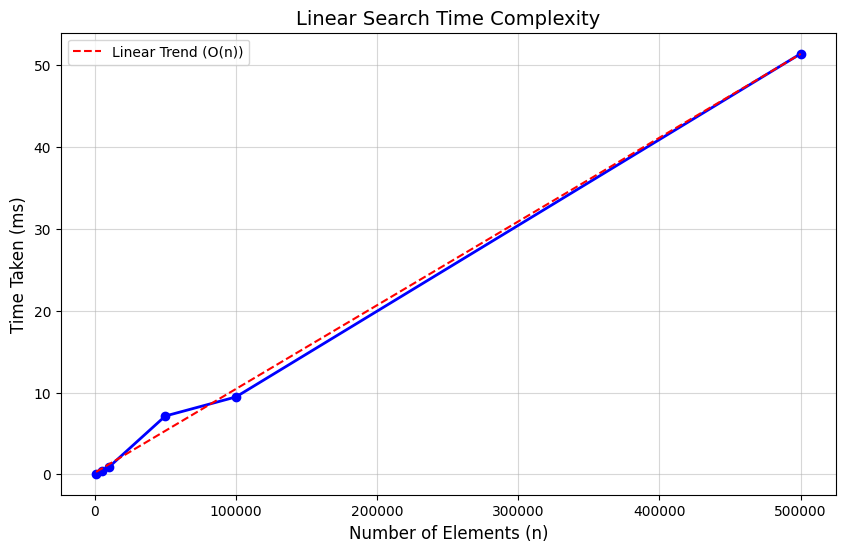

In [1]:
import timeit
import random
import matplotlib.pyplot as plt
import numpy as np

def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

n_list = [1000, 5000, 10000, 50000, 100000, 500000]
times = []

for n in n_list:
    # Generate a list of n elements
    test_list = list(range(n))
    # Search for the last element to represent the Worst Case O(n)
    target = n - 1

    start_time = timeit.default_timer()
    linear_search(test_list, target)
    end_time = timeit.default_timer()

    # Convert to milliseconds
    times.append((end_time - start_time) * 1000)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(n_list, times, marker='o', linestyle='-', color='b', linewidth=2)
plt.title("Linear Search Time Complexity", fontsize=14)
plt.xlabel("Number of Elements (n)", fontsize=12)
plt.ylabel("Time Taken (ms)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)

# Adding a trendline to show linearity
z = np.polyfit(n_list, times, 1)
p = np.poly1d(z)
plt.plot(n_list, p(n_list), "r--", label="Linear Trend (O(n))")

plt.legend()
plt.show()

# 2. Searching
Implement recursive Binary Search. Determine the time required to search an element.Repeat the experiment for different values of n, the number of elements in the list to besearched and plot a graph of the time taken versus n.
- implement recursive Binary Search, measure its time complexity for searching an element and plot a graph of time taken versus different values of n, the number of elements in the list.  
Algorithm:
1. Start with the middle element of the list
2. If the middle element matches the element being searched, return the index of the middle element
3. If the middle element is greater than the element being searched, recursively call the function on the left half of the list
4. If the middle element  is  less than the element  being searched, recursively call the function on the right half of the list
5. If the element is not found, return -1

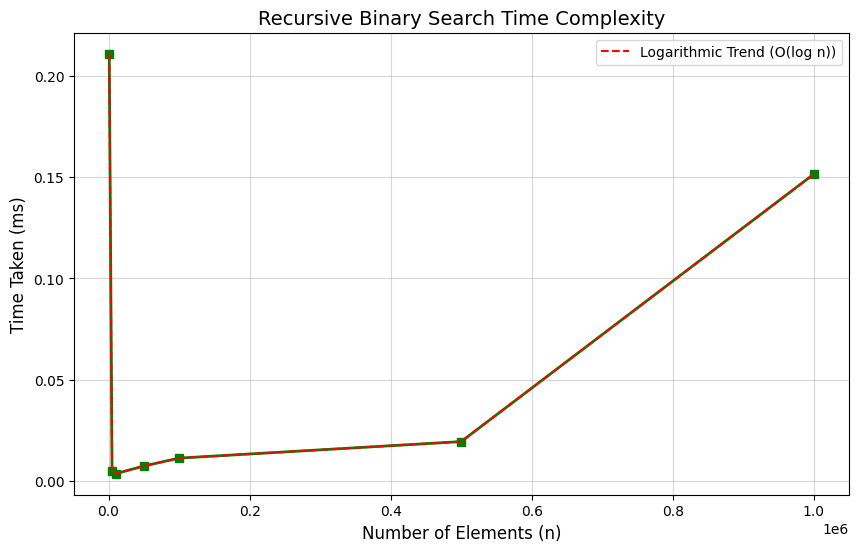

In [2]:
import timeit
import random
import matplotlib.pyplot as plt
import numpy as np
import sys

# Increase recursion depth for very large n if necessary
sys.setrecursionlimit(20000)

def binary_search_recursive(arr, low, high, target):
    if high >= low:
        mid = (high + low) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] > target:
            return binary_search_recursive(arr, low, mid - 1, target)
        else:
            return binary_search_recursive(arr, mid + 1, high, target)
    else:
        return -1

n_list = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
times = []

for n in n_list:
    # Binary search REQUIRES a sorted list
    test_list = list(range(n))
    # Searching for an element to trigger near-maximum recursion depth
    target = n - 1

    start_time = timeit.default_timer()
    binary_search_recursive(test_list, 0, len(test_list) - 1, target)
    end_time = timeit.default_timer()

    times.append((end_time - start_time) * 1000)

plt.figure(figsize=(10, 6))
plt.plot(n_list, times, marker='s', linestyle='-', color='g', linewidth=2)
plt.title("Recursive Binary Search Time Complexity", fontsize=14)
plt.xlabel("Number of Elements (n)", fontsize=12)
plt.ylabel("Time Taken (ms)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)

# Adding a logarithmic trendline
plt.plot(n_list, times, "r--", label="Logarithmic Trend (O(log n))")
plt.legend()
plt.show()

#Prob-3
Given a text txt [0...n-1] and a pattern pat [0...m-1], write a function search (char pat [ ],char txt [ ]) that prints all occurrences of pat [ ] in txt [ ]. You may assume that n > m.
- Aim:  To write a function "search" that takes a pattern and a text as input, and outputs all occurrences of the pattern in the text.  Algorithm:
1. Initialize an empty list to store the indices where the pattern occurs in the text.
2. Loop through each character in the text. For each character, check if the substring starting at that character matches the pattern.
3. If there is a match, append the starting index of the substring to the list of occurrences.
4. Continue looping through the text until all possible substrings have been checked.
5. Return the list of indices where the pattern occurs in the text.  




Text: AABAACAADAABAABA
Pattern: AABA
Occurrences found at indices: [0, 9, 12]


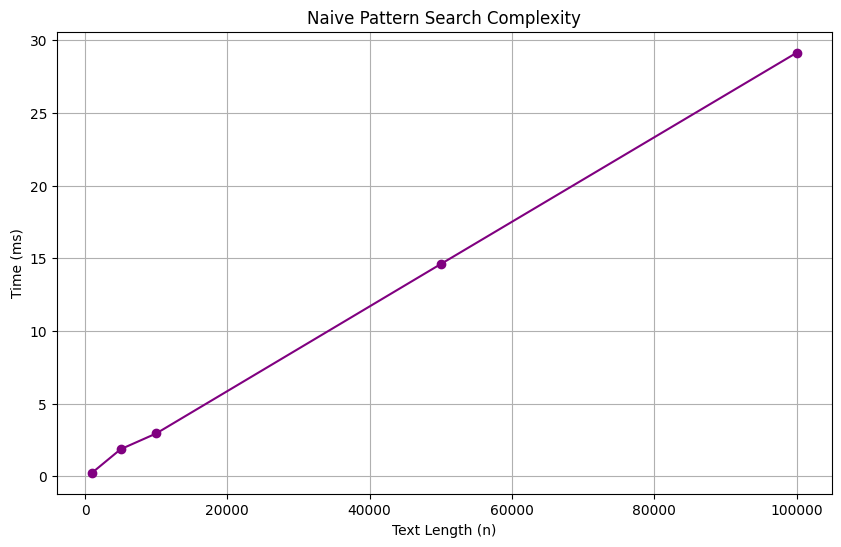

In [3]:
import timeit
import matplotlib.pyplot as plt
import random
import string

def search(pat, txt):
    m = len(pat)
    n = len(txt)
    occurrences = []

    # Loop through the text
    for i in range(n - m + 1):
        # Check if the substring matches the pattern
        if txt[i : i + m] == pat:
            occurrences.append(i)

    return occurrences

# Sample Input
txt = "AABAACAADAABAABA"
pat = "AABA"
print(f"Text: {txt}")
print(f"Pattern: {pat}")
print(f"Occurrences found at indices: {search(pat, txt)}")

# Performance Analysis
text_sizes = [1000, 5000, 10000, 50000, 100000]
search_times = []

for size in text_sizes:
    # Generate a random long text and a fixed pattern
    long_txt = ''.join(random.choices(string.ascii_uppercase, k=size))
    target_pat = "ABC"

    start = timeit.default_timer()
    search(target_pat, long_txt)
    end = timeit.default_timer()

    search_times.append((end - start) * 1000)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(text_sizes, search_times, marker='o', color='purple')
plt.title("Naive Pattern Search Complexity")
plt.xlabel("Text Length (n)")
plt.ylabel("Time (ms)")
plt.grid(True)
plt.show()

#Prob-4
Sort a given set of elements using the Insertion sort and determine the time required tosort the elements. Repeat the experiment for different values of n, the number of elements in the list to be sorted and plot a graph of the time taken versus n.  
- Aim :  To Develop a program to implement Insertion sort and determine the time required to sort the elements.  
- Algorithm:  
1. Iterate over the array from the second element to the end (i = 1 to n-1).
2. For each element, compare it to the elements before it (j = i-1 to 0).
3. If the current element is smaller, swap it with the element before it.
4. Repeat step 3 until the current element is no longer smaller than the previous element.
5. Repeat steps 2-4 for all elements in the array.

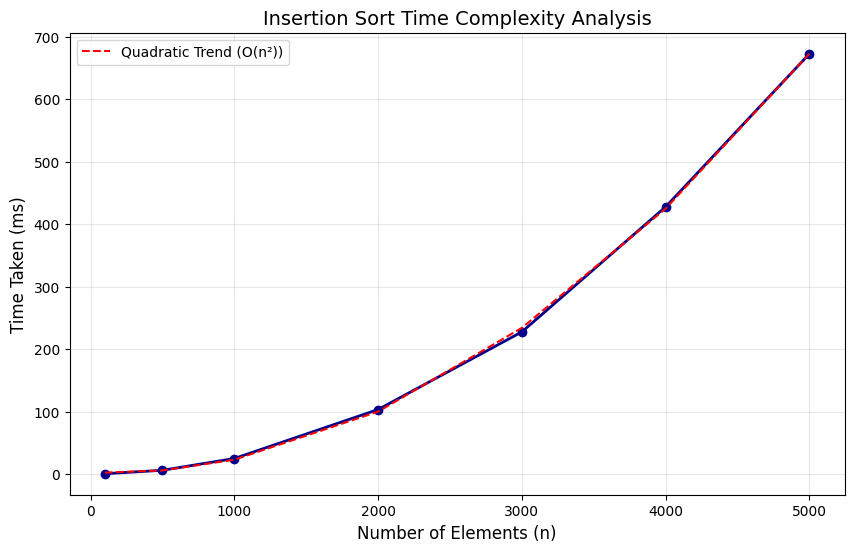

In [4]:
import timeit
import random
import matplotlib.pyplot as plt
import numpy as np

def insertion_sort(arr):
    # Step 1: Iterate from the second element to the end
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        # Step 2 & 3: Compare and move elements that are greater than the key
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        # Step 4: Place the key in its correct position
        arr[j + 1] = key
    return arr

# Experiment Configuration
n_list = [100, 500, 1000, 2000, 3000, 4000, 5000]
times = []

for n in n_list:
    # Generating a random list of size n
    test_list = [random.randint(0, 10000) for _ in range(n)]

    # Measuring time
    start_time = timeit.default_timer()
    insertion_sort(test_list)
    end_time = timeit.default_timer()

    times.append((end_time - start_time) * 1000) # Convert to ms

# Plotting the Graph
plt.figure(figsize=(10, 6))
plt.plot(n_list, times, marker='o', linestyle='-', color='darkblue', linewidth=2)
plt.title("Insertion Sort Time Complexity Analysis", fontsize=14)
plt.xlabel("Number of Elements (n)", fontsize=12)
plt.ylabel("Time Taken (ms)", fontsize=12)
plt.grid(True, alpha=0.3)

# Overlaying an O(n^2) trendline for visual confirmation
z = np.polyfit(n_list, times, 2)
p = np.poly1d(z)
plt.plot(n_list, p(n_list), "r--", label="Quadratic Trend (O(n²))")

plt.legend()
plt.show()